<a href="https://colab.research.google.com/github/fzkmdly/AirBnb/blob/main/AirBnbUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/us-airbnb-open-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'us-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/us-airbnb-open-data


In [ ]:
df = pd.read_csv('/kaggle/input/us-airbnb-open-data/AB_US_2023.csv')

df.head()

/tmp/ipykernel_3356/1654859052.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/us-airbnb-open-data/AB_US_2023.csv')


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",1169,Holly,NaN,Western Addition,37.77028,-122.43317,Entire home/apt,202,2,383,2023-02-19,2.31,1,128,59,San Francisco
1,5858,Creative Sanctuary,8904,Philip And Tania,NaN,Bernal Heights,37.74474,-122.42089,Entire home/apt,235,30,111,2017-08-06,0.66,1,365,0,San Francisco
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,NaN,Haight Ashbury,37.76555,-122.45213,Private room,56,32,9,2022-10-27,0.09,13,365,1,San Francisco
3,8339,Historic Alamo Square Victorian,24215,Rosy,NaN,Western Addition,37.77564,-122.43642,Entire home/apt,575,9,28,2019-06-28,0.17,2,365,0,San Francisco
4,8739,"Mission Sunshine, with Private Bath",7149,Ivan & Wendy,NaN,Mission,37.76030,-122.42197,Private room,110,1,770,2023-02-25,4.65,2,159,34,San Francisco


# Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232147 entries, 0 to 232146
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              232147 non-null  int64  
 1   name                            232131 non-null  object 
 2   host_id                         232147 non-null  int64  
 3   host_name                       232134 non-null  object 
 4   neighbourhood_group             96500 non-null   object 
 5   neighbourhood                   232147 non-null  object 
 6   latitude                        232147 non-null  float64
 7   longitude                       232147 non-null  float64
 8   room_type                       232147 non-null  object 
 9   price                           232147 non-null  int64  
 10  minimum_nights                  232147 non-null  int64  
 11  number_of_reviews               232147 non-null  int64  
 12  last_review     

In [ ]:
df.describe().style.format(lambda x: f'{x:.2f}')

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,232147.00,232147.00,232147.00,232147.00,232147.00,232147.00,232147.00,183062.00,232147.00,232147.00,232147.00
mean,258458021912406368.00,158224798.87,36.61,-98.30,259.47,13.50,40.92,1.64,29.88,180.99,11.69
std,346598536640873152.00,158716378.00,5.13,19.71,1024.65,27.92,80.65,1.91,106.01,134.72,20.60
min,6.00,23.00,25.96,-123.09,0.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,26388957.50,22992416.00,33.98,-118.32,91.00,2.00,1.00,0.31,1.00,52.00,0.00
50%,48963066.00,100578284.00,36.19,-97.73,149.00,3.00,9.00,1.00,2.00,175.00,3.00
75%,663301392245389184.00,268693041.50,40.72,-77.03,250.00,30.00,43.00,2.42,10.00,321.00,16.00
max,858101367585572736.00,506938352.00,47.73,-71.00,100000.00,1250.00,3091.00,101.42,1003.00,365.00,1314.00


In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,13
neighbourhood_group,135647
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.groupby('city')['neighbourhood_group'].apply(lambda x: x.isna().mean())

,neighbourhood_group
city,
Asheville,1.0
Austin,1.0
Boston,1.0
Broward County,1.0
Cambridge,1.0
Chicago,1.0
Clark County,1.0
Columbus,1.0
Denver,1.0


In [ ]:
df['neighbourhood_group'].unique()

array([nan, 'Other Cities', 'Unincorporated Areas', 'City of Los Angeles',
       'Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island',
       'Providence', 'Washington', 'Newport', 'Bristol', 'Kent',
       'Central Area', 'Other neighborhoods', 'Delridge', 'Magnolia',
       'Beacon Hill', 'West Seattle', 'Ballard', 'Queen Anne',
       'Capitol Hill', 'Downtown', 'Cascade', 'Rainier Valley',
       'Northgate', 'Lake City', 'University District', 'Seward Park',
       'Interbay'], dtype=object)

In [ ]:
df = df.drop(columns=['neighbourhood_group'])

In [ ]:
df['has_reviews'] = df['number_of_reviews'] > 0

df

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",1169,Holly,Western Addition,37.770280,-122.433170,Entire home/apt,202,2,383,2023-02-19,2.31,1,128,59,San Francisco,True
1,5858,Creative Sanctuary,8904,Philip And Tania,Bernal Heights,37.744740,-122.420890,Entire home/apt,235,30,111,2017-08-06,0.66,1,365,0,San Francisco,True
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,Haight Ashbury,37.765550,-122.452130,Private room,56,32,9,2022-10-27,0.09,13,365,1,San Francisco,True
3,8339,Historic Alamo Square Victorian,24215,Rosy,Western Addition,37.775640,-122.436420,Entire home/apt,575,9,28,2019-06-28,0.17,2,365,0,San Francisco,True
4,8739,"Mission Sunshine, with Private Bath",7149,Ivan & Wendy,Mission,37.760300,-122.421970,Private room,110,1,770,2023-02-25,4.65,2,159,34,San Francisco,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232142,849230448624862502,Private Half Moon Bay Oasis By Pillar Point Be...,29395385,Khalid,Unincorporated Areas,37.506164,-122.476188,Entire home/apt,389,2,0,NaN,NaN,1,365,0,San Mateo County,False
232143,850805127216414630,Home near SFO,440957696,Christina,San Bruno,37.623630,-122.426570,Entire home/apt,158,1,0,NaN,NaN,1,364,0,San Mateo County,False
232144,851562104616413652,Modern New Private Studio in SFO,41574587,Vality,South San Francisco,37.655661,-122.413130,Entire home/apt,97,1,0,NaN,NaN,32,359,0,San Mateo County,False
232145,851792795339759410,Lux Bedroom with a Shared Bath near SFO,73133543,Stephannie,South San Francisco,37.644792,-122.454213,Private room,62,2,0,NaN,NaN,3,67,0,San Mateo County,False


In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,13
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0


In [ ]:
df.dropna(subset=['name', 'host_name'], inplace=True)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0


# Sanity Check

## Price

In [ ]:
df['price'].describe()

,price
count,232118.000000
mean,259.460481
std,1024.683592
min,0.000000
25%,91.000000
50%,149.000000
75%,250.000000
max,100000.000000


In [ ]:
df[df['price'] == 0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
4495,48693144,Hotel Emblem San Francisco,392829961,Emily,Nob Hill,37.790258,-122.410557,Hotel room,0,1,0,NaN,NaN,1,0,0,San Francisco,False
4599,48973911,Hotel Triton San Francisco,394984266,Hotel,Financial District,37.789250,-122.404498,Hotel room,0,1,10,2023-01-29,0.46,1,0,3,San Francisco,True
5073,52498132,"Bedroom, bath and garden",2577011,Sarah,Parkside,37.739330,-122.477920,Private room,0,1,3,2021-11-28,0.18,2,0,0,San Francisco,True
10084,42738808,Capital View Hostel,312293881,Linas,"Downtown, Chinatown, Penn Quarters, Mount Vern...",38.901510,-77.015530,Hotel room,0,31,0,NaN,NaN,1,0,0,Washington D.C.,False
10495,46253554,citizenM Washington DC Capitol,374527046,CitizenM,"Southwest Employment Area, Southwest/Waterfron...",38.882860,-77.019193,Hotel room,0,1,295,2023-02-26,11.49,1,0,146,Washington D.C.,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196642,42740562,Shore Haven Resort Inn,315905144,Shore Haven Resort Inn,Lauderdale By The Sea,26.191640,-80.096830,Hotel room,0,1,0,NaN,NaN,1,0,0,Broward County,False
197865,42535198,The Cabanas Guesthouse & Spa,310483408,Cabanas,Wilton Manors,26.160060,-80.118390,Hotel room,0,1,0,NaN,NaN,1,0,0,Broward County,False
226608,42065556,Inn @ St. Botolph,107268789,Inn @,Back Bay,42.345030,-71.080850,Hotel room,0,91,20,2022-10-02,0.74,1,0,2,Boston,True
226730,46232976,citizenM Boston North Station,374414807,CitizenM,Downtown,42.364792,-71.062500,Hotel room,0,1,497,2023-03-05,18.95,1,0,149,Boston,True


In [ ]:
df[df['price'] > 5000]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
374,1059961,KelSoMa 1 Bed & Bath in SoMa,1427845,Laura,South of Market,37.780080,-122.40936,Shared room,10000,35,40,2015-11-27,0.34,1,206,0,San Francisco,True
2215,23269859,Stratford Cozy Cool Queen,173206762,Stratford,Downtown/Civic Center,37.787770,-122.40677,Private room,9999,1,5,2020-02-15,0.08,61,293,0,San Francisco,True
2217,23271162,Stratford Cozy Cool Queen,173206762,Stratford,Downtown/Civic Center,37.786510,-122.40915,Private room,9999,1,5,2019-05-20,0.10,61,293,0,San Francisco,True
2219,23271459,Stratford Cozy Cool Queen,173206762,Stratford,Downtown/Civic Center,37.787450,-122.40714,Hotel room,9999,1,3,2020-02-16,0.06,61,293,0,San Francisco,True
2220,23271549,Stratford Cool Queen,173206762,Stratford,Downtown/Civic Center,37.788160,-122.40697,Private room,9999,1,9,2020-03-02,0.15,61,293,0,San Francisco,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224489,839729662956412409,1-Bedroom Hotel Suite - 1 bed,326084746,Suiteness,Unincorporated Areas,36.116118,-115.17249,Private room,20000,1,0,NaN,NaN,327,119,0,Clark County,False
226443,39772695,"Boston Homestel, Double Bed",305274008,Boston,Dorchester,42.319430,-71.05405,Private room,10000,1,12,2020-08-02,0.30,1,0,0,Boston,True
229238,12991169,The Atherton Estate Near Stanford,22124692,Jason,Atherton,37.440720,-122.21473,Entire home/apt,5500,2,34,2020-09-10,0.42,1,0,0,San Mateo County,True
229275,10808594,4500 sq. 5x4. Great location.,55954872,Eric,Unincorporated Areas,37.573980,-122.39056,Entire home/apt,5800,3,0,NaN,NaN,1,0,0,San Mateo County,False


In [ ]:
df['price'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,price
0.01,30.0
0.05,46.0
0.25,91.0
0.50,149.0
0.75,250.0
0.95,666.0
0.99,1803.0


In [ ]:
df[df['price'] <= 0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
4495,48693144,Hotel Emblem San Francisco,392829961,Emily,Nob Hill,37.790258,-122.410557,Hotel room,0,1,0,NaN,NaN,1,0,0,San Francisco,False
4599,48973911,Hotel Triton San Francisco,394984266,Hotel,Financial District,37.789250,-122.404498,Hotel room,0,1,10,2023-01-29,0.46,1,0,3,San Francisco,True
5073,52498132,"Bedroom, bath and garden",2577011,Sarah,Parkside,37.739330,-122.477920,Private room,0,1,3,2021-11-28,0.18,2,0,0,San Francisco,True
10084,42738808,Capital View Hostel,312293881,Linas,"Downtown, Chinatown, Penn Quarters, Mount Vern...",38.901510,-77.015530,Hotel room,0,31,0,NaN,NaN,1,0,0,Washington D.C.,False
10495,46253554,citizenM Washington DC Capitol,374527046,CitizenM,"Southwest Employment Area, Southwest/Waterfron...",38.882860,-77.019193,Hotel room,0,1,295,2023-02-26,11.49,1,0,146,Washington D.C.,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196642,42740562,Shore Haven Resort Inn,315905144,Shore Haven Resort Inn,Lauderdale By The Sea,26.191640,-80.096830,Hotel room,0,1,0,NaN,NaN,1,0,0,Broward County,False
197865,42535198,The Cabanas Guesthouse & Spa,310483408,Cabanas,Wilton Manors,26.160060,-80.118390,Hotel room,0,1,0,NaN,NaN,1,0,0,Broward County,False
226608,42065556,Inn @ St. Botolph,107268789,Inn @,Back Bay,42.345030,-71.080850,Hotel room,0,91,20,2022-10-02,0.74,1,0,2,Boston,True
226730,46232976,citizenM Boston North Station,374414807,CitizenM,Downtown,42.364792,-71.062500,Hotel room,0,1,497,2023-03-05,18.95,1,0,149,Boston,True


In [ ]:
df[(df['price'] > 0) & (df['price'] < 10)]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
35267,41126644,Need to get away?? land for Rent for RV or Tent.,76557647,Anthony,Lancaster,34.69046,-118.30069,Entire home/apt,9,1,8,2023-03-06,0.39,1,365,6,Los Angeles,True
166851,19840835,Eco Friendly Tiny Apartment,3440175,James,78702,30.25438,-97.70306,Private room,5,1,1,2017-07-16,0.01,8,0,0,Austin,True
166955,20674436,Hurricane Harvey Refuge ONLY,3594051,Michael,78704,30.23928,-97.74298,Entire home/apt,1,2,2,2017-09-10,0.03,1,0,0,Austin,True


In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # pakai 3x (bukan 1.5x) karena harga properti wajar skewed

outliers = df[df['price'] > upper_bound]
print(f"Jumlah outlier: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Jumlah outlier: 10138 (4.37%)


In [ ]:
df = df[(df['price'] > 10)]

In [ ]:
cap = df['price'].quantile(0.99)
df['price_capped'] = df['price'].clip(upper=cap)

/tmp/ipykernel_3356/3707569700.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_capped'] = df['price'].clip(upper=cap)


## Minimum Nights

In [ ]:
df['minimum_nights'].describe()

,minimum_nights
count,231989.000000
mean,13.495817
std,27.925114
min,1.000000
25%,2.000000
50%,3.000000
75%,30.000000
max,1250.000000


In [ ]:
df[df['minimum_nights'] > 30]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews,price_capped
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,Haight Ashbury,37.765550,-122.452130,Private room,56,32,9,2022-10-27,0.09,13,365,1,San Francisco,True,56.0
9,12041,Sunny/Sunset view room UCSF/USF - San Francisco,21994,Aaron,Haight Ashbury,37.769010,-122.447010,Private room,65,32,7,2022-06-11,0.05,13,365,1,San Francisco,True,65.0
11,12042,Sunny/Sunset view room UCSF/USF - San Francisco*,21994,Aaron,Haight Ashbury,37.769320,-122.447230,Private room,65,32,5,2015-10-18,0.04,13,365,0,San Francisco,True,65.0
35,511991,2bed2bath Lux Living awesome amenities,723220,Helena,Financial District,37.791380,-122.397610,Entire home/apt,390,31,1,2012-09-14,0.01,1,300,0,San Francisco,True,390.0
38,519796,Lrg Sunny Flat/1 Blk fr Lombard St,2019559,Suzette,Russian Hill,37.801000,-122.424360,Entire home/apt,126,31,79,2018-12-08,0.61,1,270,0,San Francisco,True,126.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231983,792427641211747334,San Mateo Downtown Cozy 1B1B master suite,374807718,Zoe,San Mateo,37.568544,-122.331631,Private room,80,365,0,NaN,NaN,2,364,0,San Mateo County,False,80.0
232015,827702896287845213,1bd/1ba remodeled furnished condo in Crown Colony,498700219,Albert,Daly City,37.663943,-122.462956,Entire home/apt,92,60,0,NaN,NaN,1,314,0,San Mateo County,False,92.0
232060,842500529513572163,"Menlo Park 2br w/ a/c, lounge & w/d, nr Menlo ...",107434423,Blueground,Menlo Park,37.457630,-122.189538,Entire home/apt,269,31,0,NaN,NaN,183,316,0,San Mateo County,False,269.0
232092,846241465100308453,NEW! Daly City Vacation Rental w/ Furnished Patio,126644773,Evolve,Daly City,37.698502,-122.464546,Entire home/apt,161,31,0,NaN,NaN,9,361,0,San Mateo County,False,161.0


In [ ]:
df = df[df['minimum_nights'] <= 30]

In [ ]:
df[df['minimum_nights'] > 30].value_counts()

,,,,,,,,,,,,,,,,,,,count
id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews,price_capped,


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211688 entries, 0 to 232146
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              211688 non-null  int64  
 1   name                            211688 non-null  object 
 2   host_id                         211688 non-null  int64  
 3   host_name                       211688 non-null  object 
 4   neighbourhood                   211688 non-null  object 
 5   latitude                        211688 non-null  float64
 6   longitude                       211688 non-null  float64
 7   room_type                       211688 non-null  object 
 8   price                           211688 non-null  int64  
 9   minimum_nights                  211688 non-null  int64  
 10  number_of_reviews               211688 non-null  int64  
 11  last_review                     171130 non-null  object 
 12  reviews_per_month    

# Explanatory Data Analysis

In [ ]:
df.groupby('room_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,153263.0,288.596745,869.657763,11.0,121.0,180.0,296.0,100000.0
Hotel room,875.0,816.667429,1269.143303,22.0,149.0,259.0,1663.0,10000.0
Private room,55478.0,201.353329,1423.727694,12.0,55.0,78.0,120.0,100000.0
Shared room,2072.0,92.166023,364.133472,11.0,30.0,42.5,70.0,10000.0


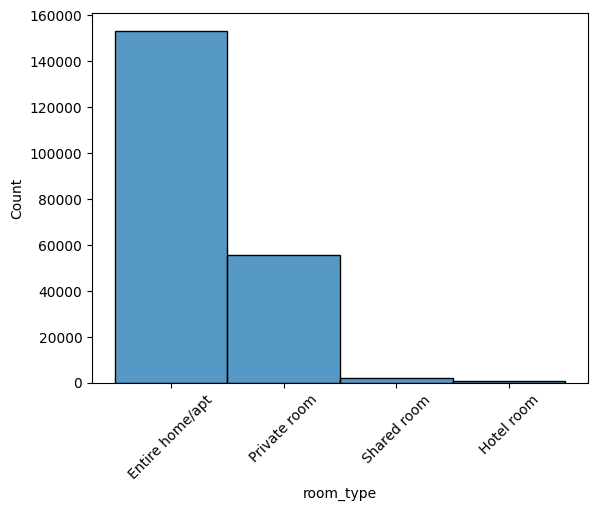

In [ ]:
sns.histplot(df, x='room_type')
plt.xticks(rotation=45)
plt.show()

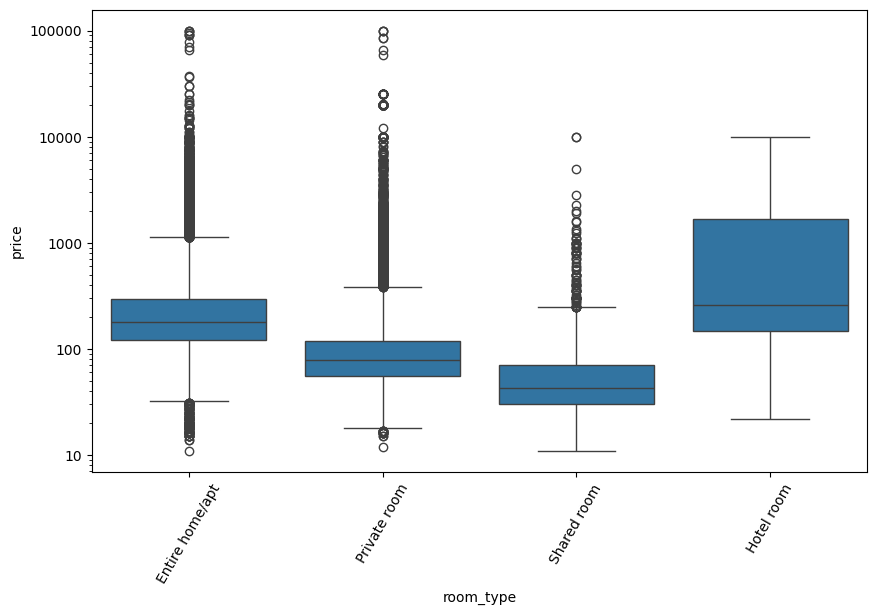

In [ ]:
from matplotlib.ticker import ScalarFormatter

# ... your existing code ...
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=df, x='room_type', y='price', log_scale=10)
plt.xticks(rotation=60)

# Change log scale formatting to plain text
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.show()

In [ ]:
df.groupby('city')['price'].median().sort_values(ascending=False)

,price
city,
Pacific Grove,250.0
Santa Cruz County,250.0
Rhode Island,223.0
Nashville,200.0
Broward County,200.0
San Diego,193.0
Clark County,189.0
Austin,181.0
New Orleans,167.0


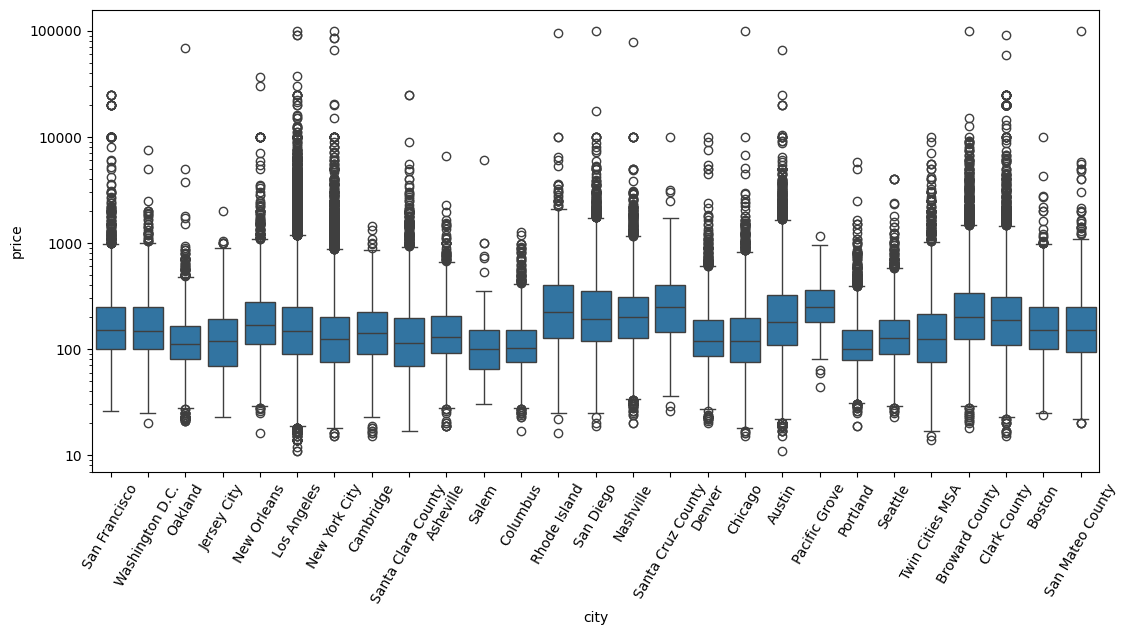

In [ ]:
from matplotlib.ticker import ScalarFormatter

# ... your existing code ...
plt.figure(figsize=(13,6))
ax = sns.boxplot(data=df, x='city', y='price', log_scale=10)
plt.xticks(rotation=60)

# Change log scale formatting to plain text
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.show()

# Feature Prep

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
y = np.log1p(df['price_capped'])
x = pd.get_dummies(df[['city', 'room_type', 'latitude', 'longitude']], drop_first=True)
x[['latitude', 'longitude']] = df[['latitude', 'longitude']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {
            "fit_intercept": [True, False]
        }
    },
    "RandomForestRegressor": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200, 500, 1000],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10],
            "max_features": ["sqrt", "log2", None]
        }
    },
    "XGBRegressor": {
        "model": XGBRegressor(random_state=42),
        "params": {
            "n_estimators": [1000, 2000, 3000, 4000, 5000],
            "learning_rate": [0.01, 0.1, 0.2, 1],
            "max_depth": [3, 5, 7, 10],
            "subsample": [0.8, 1.0]
        }
    }
}

In [ ]:
results = {}
best_estimators = {}

for name, mp in models.items():
  print(f"Running GridSearchCV for {name}...")

  grid = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"],
        cv=5,
        scoring="neg_mean_squared_error",  # or "r2", "neg_mean_absolute_error", etc.
        n_jobs=1, # Changed from -1 to 1 to reduce memory usage
        verbose=1
    )
  grid.fit(X_train, y_train)

  results[name] = {
      "best_params": grid.best_params_,
      "best_score": grid.best_score_,
      "best_estimator": grid.best_estimator_
  }
  best_estimators[name] = grid.best_estimator_

  print(f"Best params for {name}: {grid.best_params_}")
  print(f"Best CV score for {name}: {grid.best_score_:.4f}\n")

Running GridSearchCV for LinearRegression...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best params for LinearRegression: {'fit_intercept': True}
Best CV score for LinearRegression: -0.4670

Running GridSearchCV for RandomForestRegressor...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

for name, est in best_estimators.items():
    preds = est.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name}: MSE={mse:.4f}, R2={r2:.4f}")